# Regenerate cost-per-correct values and the Pareto figure

Standalone notebook that reads the existing `e5_cost_{swat,hai,wustl}.csv` files,
recomputes `cost_usd` and `cost_per_correct_usd` with the corrected Qwen3 pricing
(Nebius May-2026 verified: $0.20 / $0.60 per 1M tokens, was $0.30 / $0.90 in v10),
and regenerates the cost-vs-macroF1 Pareto plot used as Figure fig_cost_pareto
in the manuscript.

Run order: edit `INPUT_DIR` in cell 3 to point at the directory containing
your three `e5_cost_*.csv` files, then run all cells. Outputs land in
`./cost_regen_outputs/`.

In [1]:
# Cell 1 -- imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cell 2 -- pricing snapshot
# Per-1M-token Nebius public-tariff snapshot, verified against the Nebius
# pricing page in May 2026. The ONLY change relative to the v10 notebook
# is Qwen3-235B-A22B, which moved from 0.30 / 0.90 to 0.20 / 0.60.
PRICE_PER_1M_INPUT = {
    'Llama-3.3-70B'   : 0.13,
    'Qwen3-235B-A22B' : 0.20,   # CORRECTED (was 0.30)
    'Hermes-4-70B'    : 0.13,
    'Hermes-4-405B'   : 1.00,
}
PRICE_PER_1M_OUTPUT = {
    'Llama-3.3-70B'   : 0.40,
    'Qwen3-235B-A22B' : 0.60,   # CORRECTED (was 0.90)
    'Hermes-4-70B'    : 0.40,
    'Hermes-4-405B'   : 3.00,
}
for k, v in PRICE_PER_1M_INPUT.items():
    print(f'  {k:18s}  in=${v:.2f}/M   out=${PRICE_PER_1M_OUTPUT[k]:.2f}/M')

  Llama-3.3-70B       in=$0.13/M   out=$0.40/M
  Qwen3-235B-A22B     in=$0.20/M   out=$0.60/M
  Hermes-4-70B        in=$0.13/M   out=$0.40/M
  Hermes-4-405B       in=$1.00/M   out=$3.00/M


In [3]:
# Cell 3 -- paths
# EDIT THIS: directory containing e5_cost_swat.csv, e5_cost_hai.csv, e5_cost_wustl.csv
INPUT_DIR  = './'

OUTPUT_DIR = './cost_regen_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS = ['swat', 'hai', 'wustl']

# Sanity-check that the CSVs are where expected
for ds in DATASETS:
    p = os.path.join(INPUT_DIR, f'e5_cost_{ds}.csv')
    print(f'  {p}  -->  {"OK" if os.path.isfile(p) else "MISSING"}')

  ./e5_cost_swat.csv  -->  OK
  ./e5_cost_hai.csv  -->  OK
  ./e5_cost_wustl.csv  -->  OK


In [4]:
# Cell 4 -- recompute costs with the new pricing
def recompute(df):
    '''Recompute cost_usd and cost_per_correct_usd given the new prices.
       Preserves all original columns; adds *_new columns.
    '''
    df = df.copy()
    df['cost_usd_new'] = (
        df['prompt_tok']     / 1e6 * df['model'].map(PRICE_PER_1M_INPUT)
        + df['completion_tok'] / 1e6 * df['model'].map(PRICE_PER_1M_OUTPUT)
    )
    # Recover the effective n_test from the original ratio so the notebook
    # is robust to whatever sample count E5 used per dataset (typically 100).
    df['n_test'] = np.round(
        df['cost_usd'] / (df['cost_per_correct_usd'] * df['accuracy'].clip(lower=1e-9))
    ).astype(int)
    df['cost_per_correct_usd_new'] = (
        df['cost_usd_new'] / (df['accuracy'].clip(lower=1e-9) * df['n_test'])
    )
    return df

results = {}
for ds in DATASETS:
    csv_path = os.path.join(INPUT_DIR, f'e5_cost_{ds}.csv')
    if not os.path.isfile(csv_path):
        print(f'SKIP {ds}: file not found')
        continue
    df = pd.read_csv(csv_path)
    # Keep only the four LLMs of interest (drop any extras)
    df = df[df['model'].isin(PRICE_PER_1M_INPUT.keys())].reset_index(drop=True)
    df_new = recompute(df)

    # Sanity check: prices unchanged for non-Qwen3 models
    for _, r in df_new.iterrows():
        if r['model'] != 'Qwen3-235B-A22B':
            diff = abs(r['cost_usd_new'] - r['cost_usd'])
            if diff > 1e-5:
                print(f'  WARNING: {r["model"]} on {ds} cost changed by ${diff:.6f} '
                      f'(maybe v10 used different prices for this model than expected)')

    results[ds] = df_new
    df_new.to_csv(os.path.join(OUTPUT_DIR, f'e5_cost_{ds}_regen.csv'), index=False)
    print(f'\n--- {ds.upper()} ---')
    cols = ['model', 'macro_f1', 'accuracy', 'n_test',
            'cost_usd', 'cost_usd_new',
            'cost_per_correct_usd', 'cost_per_correct_usd_new']
    print(df_new[cols].round(6).to_string(index=False))


--- SWAT ---
          model  macro_f1  accuracy  n_test  cost_usd  cost_usd_new  cost_per_correct_usd  cost_per_correct_usd_new
  Llama-3.3-70B  0.835796      0.84     100  0.072481      0.072481              0.000863                  0.000863
   Hermes-4-70B  0.696970      0.70     100  0.071703      0.071703              0.001024                  0.001024
Qwen3-235B-A22B  0.824941      0.83     100  0.300823      0.200549              0.003624                  0.002416
  Hermes-4-405B  0.802884      0.81     100  0.551502      0.551502              0.006809                  0.006809

--- HAI ---
          model  macro_f1  accuracy  n_test  cost_usd  cost_usd_new  cost_per_correct_usd  cost_per_correct_usd_new
  Llama-3.3-70B  0.660179      0.67     100  0.079766      0.079766              0.001191                  0.001191
   Hermes-4-70B  0.435028      0.53     100  0.078986      0.078986              0.001490                  0.001490
Qwen3-235B-A22B  0.677939      0.68     100  

Wrote ./cost_regen_outputs/fig_cost_pareto.png
Wrote ./cost_regen_outputs/fig_cost_pareto.pdf


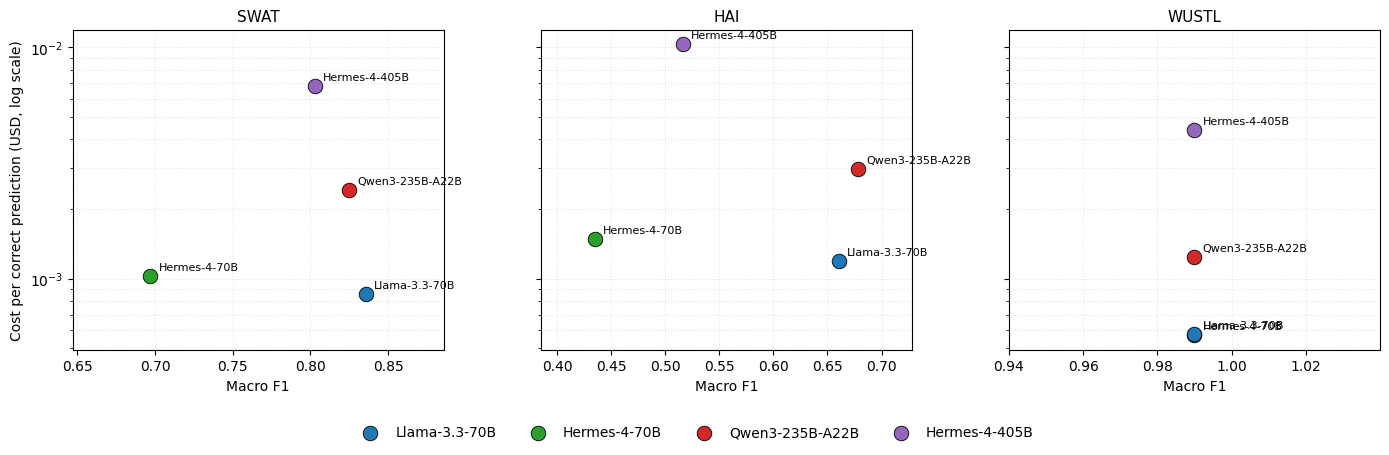

In [5]:
# Cell 5 -- Pareto plot (3 panels, one per dataset)
COLOR = {
    'Llama-3.3-70B'   : '#1f77b4',
    'Qwen3-235B-A22B' : '#d62728',
    'Hermes-4-70B'    : '#2ca02c',
    'Hermes-4-405B'   : '#9467bd',
}
MARKER_SIZE = 110

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)

for ax, ds in zip(axes, DATASETS):
    if ds not in results:
        ax.text(0.5, 0.5, f'No data for {ds}', ha='center', va='center',
                transform=ax.transAxes)
        continue
    df = results[ds]
    for _, r in df.iterrows():
        ax.scatter(
            r['macro_f1'], r['cost_per_correct_usd_new'],
            s=MARKER_SIZE, marker='o',
            facecolor=COLOR[r['model']], edgecolor='black', linewidth=0.6,
            label=r['model'], zorder=3,
        )
        ax.annotate(
            r['model'],
            (r['macro_f1'], r['cost_per_correct_usd_new']),
            xytext=(6, 4), textcoords='offset points', fontsize=8,
        )
    ax.set_yscale('log')
    ax.set_xlabel('Macro F1')
    ax.set_title(ds.upper(), fontsize=11)
    ax.grid(alpha=0.3, which='both', linestyle=':')
    # Pad x-axis a bit so the annotations don't overflow
    xmin = max(0.0, df['macro_f1'].min() - 0.05)
    xmax = min(1.05, df['macro_f1'].max() + 0.05)
    ax.set_xlim(xmin, xmax)

axes[0].set_ylabel('Cost per correct prediction (USD, log scale)')

# Single combined legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))   # deduplicate per-axis duplicates
fig.legend(by_label.values(), by_label.keys(),
           loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.06, 1, 1])
out_png = os.path.join(OUTPUT_DIR, 'fig_cost_pareto.png')
out_pdf = os.path.join(OUTPUT_DIR, 'fig_cost_pareto.pdf')
plt.savefig(out_png, dpi=200, bbox_inches='tight')
plt.savefig(out_pdf, bbox_inches='tight')
print(f'Wrote {out_png}')
print(f'Wrote {out_pdf}')
plt.show()

In [6]:
# Cell 6 -- ready-to-paste summary numbers for the manuscript
print('\n=== Updated cost-per-correct values for §5.5 prose ===')
for ds in DATASETS:
    if ds not in results:
        continue
    df = results[ds].sort_values('cost_per_correct_usd_new')
    print(f'\n{ds.upper()}:')
    for _, r in df.iterrows():
        delta = r['cost_per_correct_usd_new'] - r['cost_per_correct_usd']
        flag  = '  (CHANGED)' if abs(delta) > 1e-9 else ''
        print(f'  {r["model"]:18s}  macroF1={r["macro_f1"]:.3f}  '
              f'cost/correct = ${r["cost_per_correct_usd_new"]:.3e}{flag}')

# Cheapest / dominated pair for SWaT (the order-of-magnitude claim in §6.4)
if 'swat' in results:
    s = results['swat']
    cheapest = s.loc[s['cost_per_correct_usd_new'].idxmin()]
    most_exp = s.loc[s['cost_per_correct_usd_new'].idxmax()]
    ratio    = most_exp['cost_per_correct_usd_new'] / cheapest['cost_per_correct_usd_new']
    print(f'\nSWaT order-of-magnitude sanity check (for §6.4):')
    print(f'  cheapest    : {cheapest["model"]:18s}  ${cheapest["cost_per_correct_usd_new"]:.3e}')
    print(f'  most expensive: {most_exp["model"]:16s}  ${most_exp["cost_per_correct_usd_new"]:.3e}')
    print(f'  ratio       : {ratio:.1f}x')
    print(f'  --> the "approximately an order of magnitude" claim in §6.4 ',
          'holds' if ratio >= 8 else 'NO LONGER HOLDS -- consider rephrasing')


=== Updated cost-per-correct values for §5.5 prose ===

SWAT:
  Llama-3.3-70B       macroF1=0.836  cost/correct = $8.629e-04
  Hermes-4-70B        macroF1=0.697  cost/correct = $1.024e-03
  Qwen3-235B-A22B     macroF1=0.825  cost/correct = $2.416e-03  (CHANGED)
  Hermes-4-405B       macroF1=0.803  cost/correct = $6.809e-03

HAI:
  Llama-3.3-70B       macroF1=0.660  cost/correct = $1.191e-03
  Hermes-4-70B        macroF1=0.435  cost/correct = $1.490e-03
  Qwen3-235B-A22B     macroF1=0.678  cost/correct = $2.976e-03  (CHANGED)
  Hermes-4-405B       macroF1=0.516  cost/correct = $1.030e-02

WUSTL:
  Hermes-4-70B        macroF1=0.990  cost/correct = $5.707e-04
  Llama-3.3-70B       macroF1=0.990  cost/correct = $5.786e-04
  Qwen3-235B-A22B     macroF1=0.990  cost/correct = $1.237e-03  (CHANGED)
  Hermes-4-405B       macroF1=0.990  cost/correct = $4.390e-03

SWaT order-of-magnitude sanity check (for §6.4):
  cheapest    : Llama-3.3-70B       $8.629e-04
  most expensive: Hermes-4-405B     $

In [7]:
# Cell 7 -- download all regenerated files (Colab)
from google.colab import files
import os

for fn in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, fn)
    print(f'Downloading {path}')
    files.download(path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>